In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [3]:
runways = pd.read_csv(
    "../../../data/processed/airports/runways/runways_processed.csv"
)

In [4]:
runways.head()

,id,airport_ref,airport_ident,length_ft,width_ft,surface,lighted,closed,le_ident,le_latitude_deg,le_longitude_deg,le_elevation_ft,le_heading_degT,le_displaced_threshold_ft,he_ident,he_latitude_deg,he_longitude_deg,he_elevation_ft,he_heading_degT,he_displaced_threshold_ft
0,269408,6523,00A,80.0,80.0,ASPH-G,1,0,H1,NaN,NaN,NaN,NaN,NaN,UNKNOWN,NaN,NaN,NaN,NaN,NaN
1,255155,6524,00AK,2500.0,40.0,GRVL,0,0,N,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN
2,254165,6525,00AL,2100.0,90.0,TURF,0,0,01,NaN,NaN,NaN,NaN,NaN,19,NaN,NaN,NaN,NaN,NaN
3,506792,506791,00AN,4517.0,60.0,GVL,0,0,3,NaN,NaN,NaN,NaN,NaN,21,NaN,NaN,NaN,NaN,NaN
4,322128,322127,00AS,1450.0,60.0,TURF,0,0,1,NaN,NaN,NaN,NaN,NaN,19,NaN,NaN,NaN,NaN,NaN


In [5]:
runways.shape

(48074, 20)

In [6]:
runways.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48074 entries, 0 to 48073
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         48074 non-null  int64  
 1   airport_ref                48074 non-null  int64  
 2   airport_ident              48074 non-null  object 
 3   length_ft                  48074 non-null  float64
 4   width_ft                   48074 non-null  float64
 5   surface                    48074 non-null  object 
 6   lighted                    48074 non-null  int64  
 7   closed                     48074 non-null  int64  
 8   le_ident                   48074 non-null  object 
 9   le_latitude_deg            15663 non-null  float64
 10  le_longitude_deg           15650 non-null  float64
 11  le_elevation_ft            13300 non-null  float64
 12  le_heading_degT            15075 non-null  float64
 13  le_displaced_threshold_ft  3067 non-null   flo

In [7]:
numerical_columns = [
    "length_ft",
    "width_ft"
]

In [8]:
runways[numerical_columns].describe()

,length_ft,width_ft
count,48074.00000,48074.000000
mean,3208.88006,104.230104
std,2705.41597,207.834742
min,0.00000,-1.000000
25%,1600.00000,59.000000
50%,2650.00000,75.000000
75%,4132.50000,100.000000
max,30000.00000,9000.000000


In [9]:
runways[numerical_columns].skew()

length_ft     1.382401
width_ft     17.228379
dtype: float64

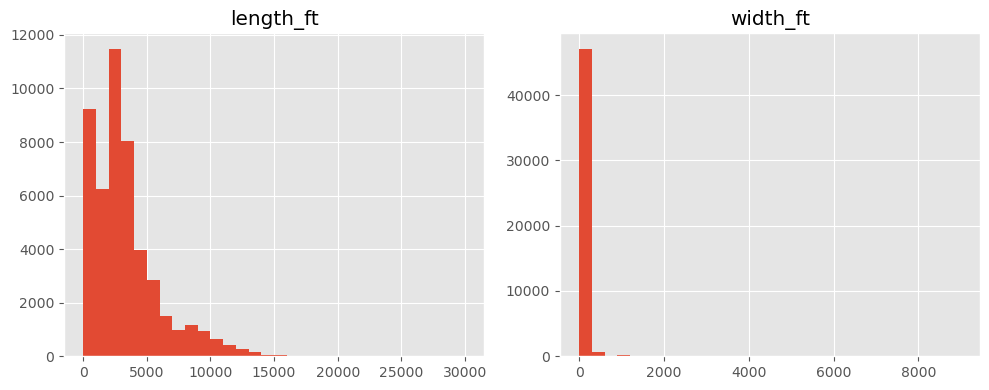

In [10]:
runways[numerical_columns].hist(
    figsize=(10,4),
    bins=30
)

plt.tight_layout()
plt.show()

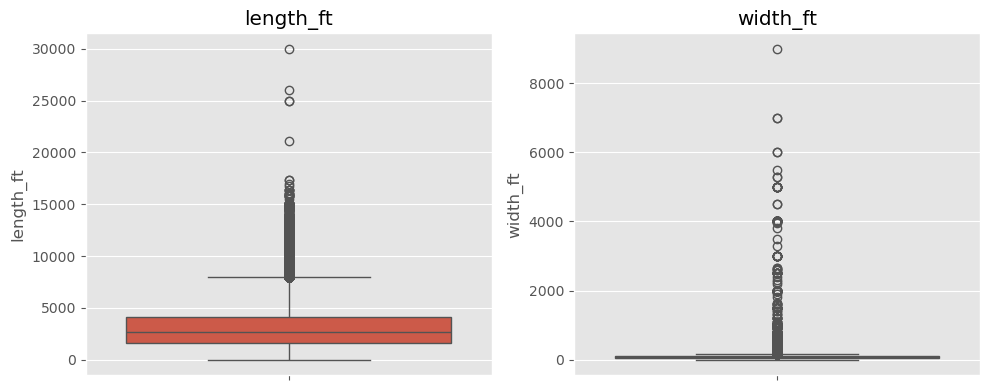

In [11]:
plt.figure(figsize=(10,4))

for i, column in enumerate(numerical_columns):

    plt.subplot(1,2,i+1)

    sns.boxplot(
        y=runways[column]
    )

    plt.title(column)

plt.tight_layout()
plt.show()

In [12]:
surface = runways["surface"].value_counts().head(20)

surface

surface
ASP        11367
TURF        8803
CON         3640
CONC        3104
GRS         2240
ASPH        1678
GRE         1538
GRASS       1251
GVL         1061
TURF-G      1013
WATER        719
DIRT         696
EARTH        640
ASPH-G       617
UNKNOWN      505
ASPHALT      494
TURF-F       494
UNK          487
G            472
X            416
Name: count, dtype: int64

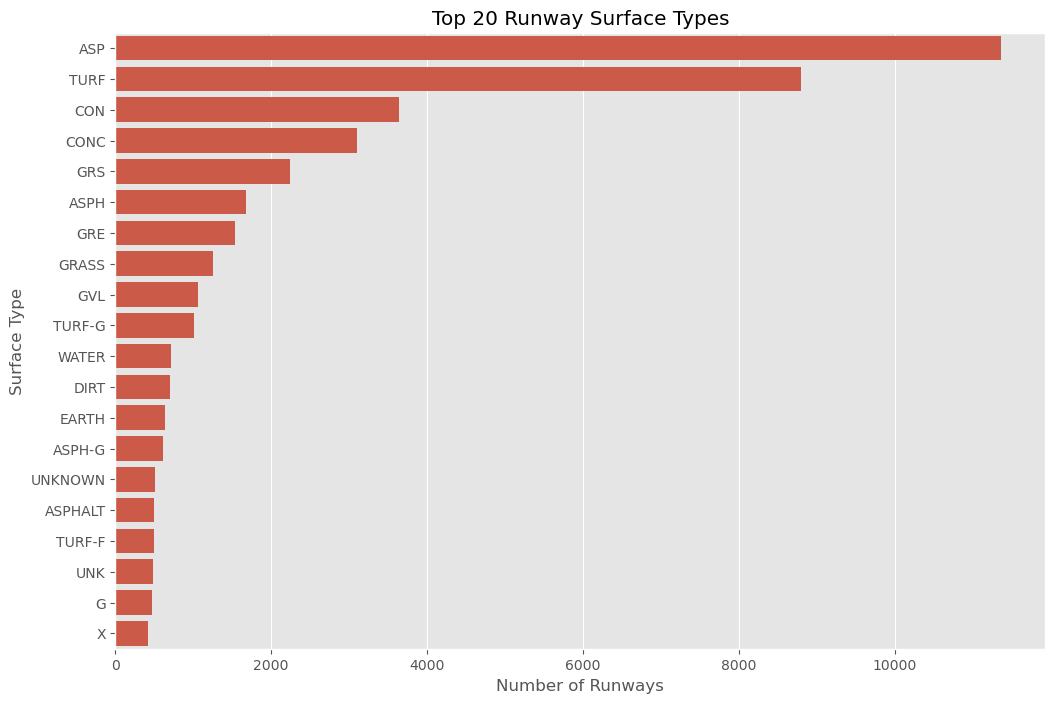

In [13]:
plt.figure(figsize=(12,8))

sns.barplot(
    x=surface.values,
    y=surface.index
)

plt.title("Top 20 Runway Surface Types")

plt.xlabel("Number of Runways")

plt.ylabel("Surface Type")

plt.show()

In [14]:
runways["lighted"].value_counts()

lighted
0    35754
1    12320
Name: count, dtype: int64

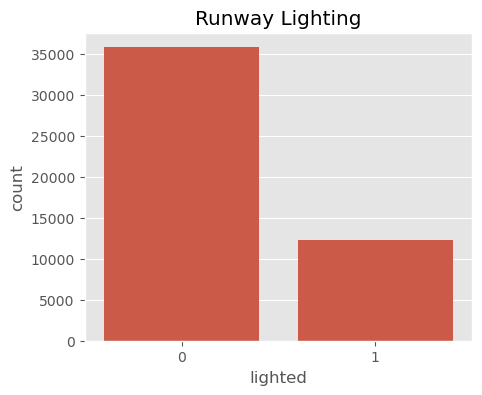

In [15]:
plt.figure(figsize=(5,4))

sns.countplot(
    x="lighted",
    data=runways
)

plt.title("Runway Lighting")

plt.show()

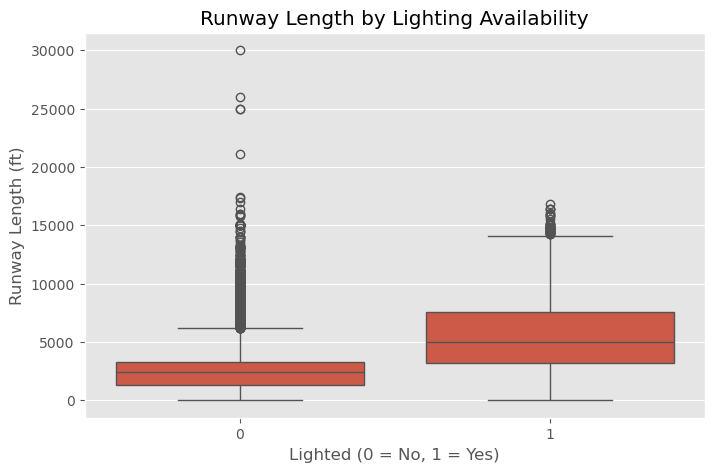

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="lighted",
    y="length_ft",
    data=runways
)

plt.title("Runway Length by Lighting Availability")

plt.xlabel("Lighted (0 = No, 1 = Yes)")
plt.ylabel("Runway Length (ft)")

plt.show()

In [16]:
runways["closed"].value_counts()

closed
0    47023
1     1051
Name: count, dtype: int64

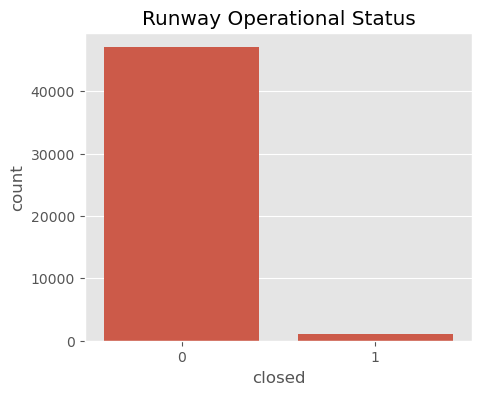

In [17]:
plt.figure(figsize=(5,4))

sns.countplot(
    x="closed",
    data=runways
)

plt.title("Runway Operational Status")

plt.show()

In [18]:
correlation = runways[numerical_columns].corr()

correlation

,length_ft,width_ft
length_ft,1.000000,0.247925
width_ft,0.247925,1.000000


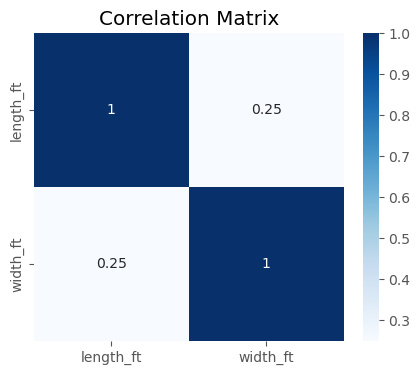

In [19]:
plt.figure(figsize=(5,4))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()

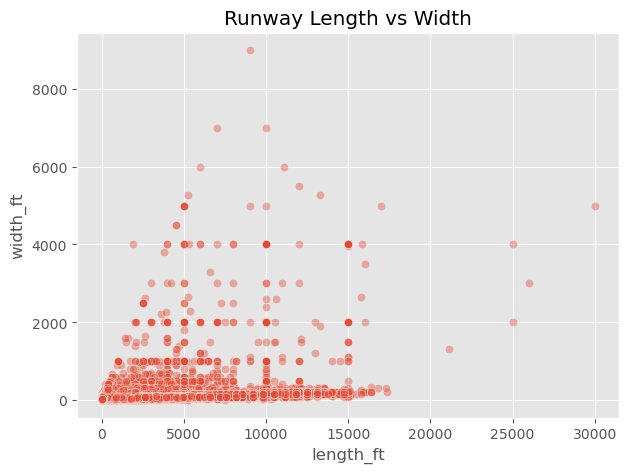

In [20]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=runways,
    x="length_ft",
    y="width_ft",
    alpha=0.4
)

plt.title("Runway Length vs Width")

plt.show()

In [21]:
surface_length = (
    runways
    .groupby("surface")["length_ft"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

surface_length

surface
ASHPHALT            11700.000000
CONC-GRVD           11062.500000
CONCRETE AND ASP    10437.000000
BLUE ICE            10197.333333
COMPOSITE            9035.000000
SALT                 9000.000000
ASPH 71/F/C/X/T      8858.000000
MARSTON MAT          8520.000000
PEM                  8413.288184
CONC-ASPH            8212.000000
CON/ASP              8202.500000
CONCRETE/GROOVED     8000.000000
CEMENT               7874.000000
CEM                  7874.000000
ICE                  7523.666667
Name: length_ft, dtype: float64

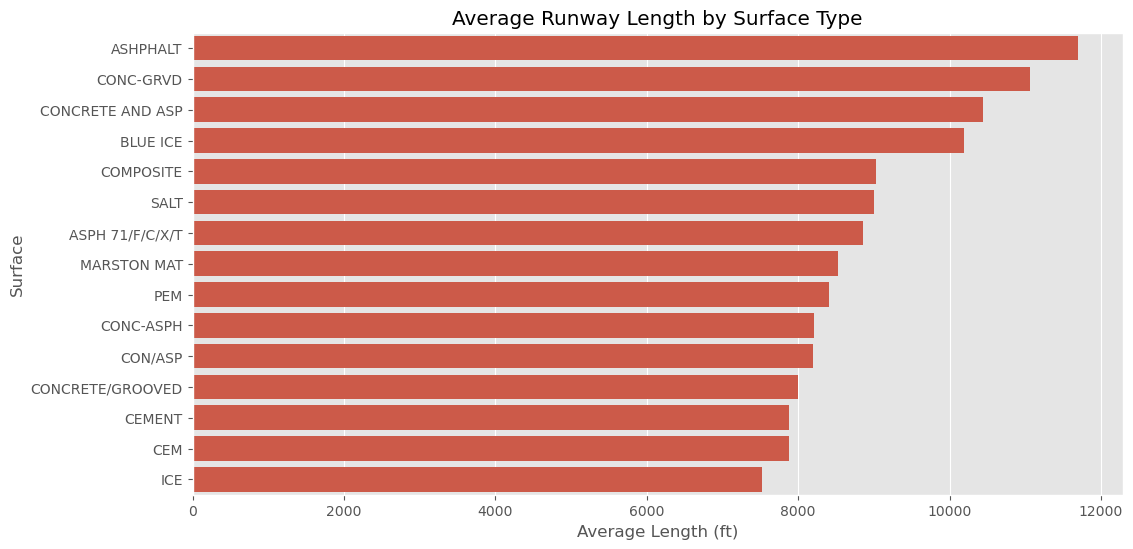

In [22]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=surface_length.values,
    y=surface_length.index
)

plt.title("Average Runway Length by Surface Type")

plt.xlabel("Average Length (ft)")

plt.ylabel("Surface")

plt.show()

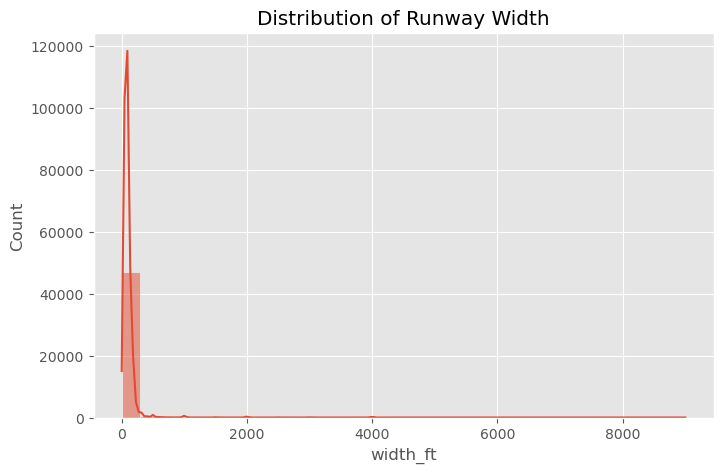

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    runways["width_ft"],
    bins=30,
    kde=True
)

plt.title("Distribution of Runway Width")

plt.show()

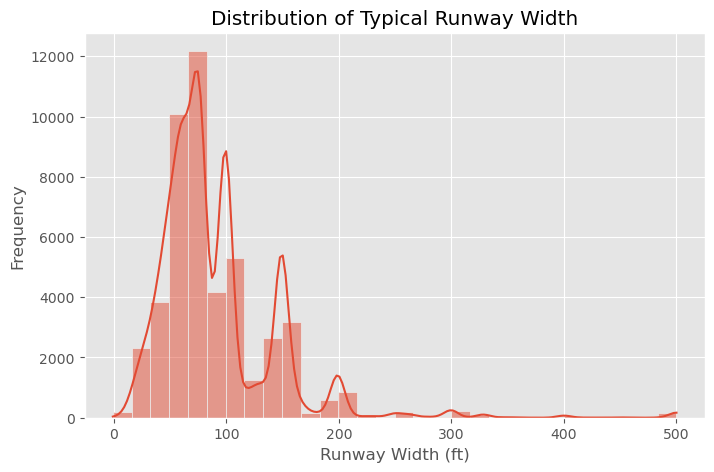

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    runways[
        runways["width_ft"] <= 500
    ]["width_ft"],
    bins=30,
    kde=True
)

plt.title("Distribution of Typical Runway Width")

plt.xlabel("Runway Width (ft)")
plt.ylabel("Frequency")

plt.show()

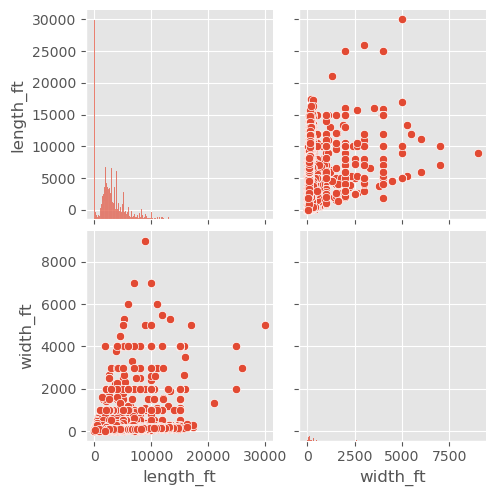

In [24]:
sns.pairplot(
    runways[numerical_columns]
)

plt.show()

## Exploratory Data Analysis Summary

The runway dataset provides detailed operational information about airport runway infrastructure worldwide. Most runways are paved using asphalt or concrete, while grass and gravel runways are commonly associated with smaller regional or private airfields. The majority of runways are operational and a substantial proportion support night operations through runway lighting. Runway length and width vary considerably depending on airport operational requirements, with longer runways generally associated with greater runway widths. These findings provide valuable operational context that will support the creation of runway capability features during the feature engineering stage and later contribute to airport capability assessment within the proposed Flight Operations Analytics and Decision Support Dashboard.